### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/CIFAR100%20UNet%20Diffusion%202.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Ffiles%2Fnotebooks%2FCIFAR100%2520UNet%2520Diffusion%25202.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Ffiles%2Fnotebooks%2FCIFAR100%20UNet%20Diffusion%202.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/CIFAR100%20UNet%20Diffusion%202.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [1]:
"""Prepare a notebook checkout and runtime before importing scientific packages.

This canonical first-cell source is copied into maintained notebooks and generated
HPO notebooks. Edit REVISION/RUNTIME/CUDA before execution when needed. Existing
checkouts are reused without fetching; only missing setup code is downloaded.
ROOT is the selected absolute pathlib.Path; RUNTIME_PACKAGES maps package names
to installed version strings. Preparation may clone/install under the selected
policy and changes cwd/import paths through files.notebooks.init.prepare_notebook.
"""
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME, 
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "files" / "notebooks" / "init.py" for path in _locations
                     if (path / "files" / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/files/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, 
    repository=REPOSITORY, 
    revision=REVISION, 
    runtime=RUNTIME, 
    cuda=CUDA
)

Repository ready: /workspace/UNet-HPO (runtime: local)
Runtime packages ready: Python 3.12.3, TensorFlow 2.20.0, Keras 3.11.2


In [2]:
from common import utils
from common.dataloader import get_dataset


utils.init()

2026-10-10 12:56:33.545608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-10 12:56:33.616195: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-10 12:56:35.266303: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Experiment settings

HPO finalist trial 23: second candidate with transposed-convolution upsampling.

These settings were selected by CIFAR-10 HPO and transferred to CIFAR-100; their ranking on CIFAR-100 has not been established. Train fresh 100-class weights.


In [3]:
from tensorflow import keras


epochs = 50
batch_size = 64
val_freq = 5
seed = 42

keras.utils.set_random_seed(seed)

## CIFAR100 data

Keep raw pixel values and labels 0–99; the wrapper handles image preprocessing and CFG label mapping. Reserve 20% of the training split for validation, keeping the official test split separate.


In [4]:
from common.dataloader import load_cifar100


x_train, y_train, x_val, y_val, x_test, y_test = load_cifar100(
    indices=None, 
    validation_ratio=0.2, 
    verbose=0, 
    seed=seed
)

trainset = get_dataset(
    x_train, 
    y_train.reshape(-1), 
    batch_size=batch_size, 
    seed=seed
)
valset = get_dataset(
    x_val, 
    y_val.reshape(-1), 
    batch_size=batch_size, 
    shuffle_buffer=0, 
    drop_remainder=False
)

2026-10-10 12:56:56.618545: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1791637016.619499   37827 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 72553 MB memory:  -> device: 0, name: NVIDIA H100 PCIe, pci bus id: 0000:d6:00.0, compute capability: 9.0


## UNet denoiser

Use encoder/decoder widths 64, 128 and 256, with three blocks per level and a 384-channel bottleneck of depth two, with time and class conditioning. Train the surrounding diffusion wrapper.


In [5]:
from diffusion.models.convolution.unet import UNet
from diffusion.models.wrapper.diffusion_model import DiffusionModel


unet = UNet(
    num_classes=100, 
    use_cfg=True, 
    image_size=32, 
    channels=3, 
    widths=(64, 128, 256), 
    block_depth=3, 
    bottleneck_width=384, 
    bottleneck_depth=2, 
    activation_func="gelu", 
    upsampling_method="cnn_transpose", 
    upsampling_interpolation="bilinear", 
    seed=seed
)
model = DiffusionModel(
    network=unet, 
    p_uncond=0.2, 
    seed=seed
)

unet.summary()

Model: "u_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_embedder (Conv2D)         │ (None, 32, 32, 21)     │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_embedder                   │ (None, 22)             │        22,000 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ label_embedder                  │ (None, 21)             │         2,121 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_1 (LayerDict)             │ (None, 32, 32, 64)     │       230,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_2 (LayerDict)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_3 (LayerDict)             │ (None, 16, 16, 128)    │       837,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_4 (LayerDict)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_5 (LayerDict)             │ (None, 8, 8, 256)      │     3,313,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_6 (LayerDict)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_7 (LayerDict)             │ (None, 4, 4, 384)      │     5,001,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_8 (LayerDict)             │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_9 (LayerDict)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_10 (LayerDict)            │ (None, 8, 8, 256)      │     4,297,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_11 (LayerDict)            │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_12 (LayerDict)            │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_13 (LayerDict)            │ (None, 16, 16, 128)    │     1,083,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_14 (LayerDict)            │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_15 (LayerDict)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_16 (LayerDict)            │ (None, 32, 32, 64)     │       275,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ noise_projection (Conv2D)       │ (None, 32, 32, 3)      │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_noise (Activation)    │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,318,160 (62.25 MB)

 Trainable params: 16,288,992 (62.14 MB)

 Non-trainable params: 29,168 (113.94 KB)

## Optimizer

Use AdamW with the candidate learning rate and weight decay, cosine decay, and mean squared noise-prediction error.


In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0009232173954634668, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.AdamW(
        lr_schedule, 
        weight_decay=1.0569549424860102e-05
    ), 
    loss="mse"
)

## Training

Train on the training partition and validate every epoch. Early stopping restores the best validation noise-loss weights with patience 5 and min_delta 0.001. Sample previews still run every `val_freq` epochs.


In [7]:
from tensorflow.keras import callbacks

from diffusion.callbacks.image_generator import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    callbacks.EarlyStopping(
        monitor="val_noise_loss", 
        mode="min", 
        patience=5, 
        min_delta=0.001, 
        restore_best_weights=True
    ), 
    ImageGenerator(
        frequency=val_freq, 
        seed=seed
    )
]

Epoch 1/50


2026-10-10 12:57:32.664172: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d008c001b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-10-10 12:57:32.664219: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA H100 PCIe, Compute Capability 9.0
2026-10-10 12:57:33.635740: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-10-10 12:57:37.922163: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-10-10 12:57:39.826352: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-10-10 12:57:39.826394: I external

  3/625 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - noise_loss: 0.9939     

I0000 00:00:1791637126.887022   38745 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - noise_loss: 0.1240

2026-10-10 12:59:09.822349: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-10-10 12:59:12.596494: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_62', 28 bytes spill stores, 28 bytes spill loads

2026-10-10 12:59:13.203924: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_62', 168 bytes spill stores, 160 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 159s 95ms/step - noise_loss: 0.0599 - val_image_loss: 27.6319 - val_loss: 0.7789 - val_noise_loss: 0.7789 - learning_rate: 9.2231e-04
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0351 - val_image_loss: 15.3978 - val_loss: 0.4613 - val_noise_loss: 0.4613 - learning_rate: 9.1958e-04
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - noise_loss: 0.0332 - val_image_loss: 6.6919 - val_loss: 0.2331 - val_noise_loss: 0.2331 - learning_rate: 9.1504e-04
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0323 - val_image_loss: 2.1945 - val_loss: 0.1113 - val_noise_loss: 0.1113 - learning_rate: 9.0872e-04
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0318 - val_image_loss: 0.6081 - val_loss: 0.0609 - val_noise_loss: 0.0609 - learning_rate: 9.0062e-04
Steps: 50/50


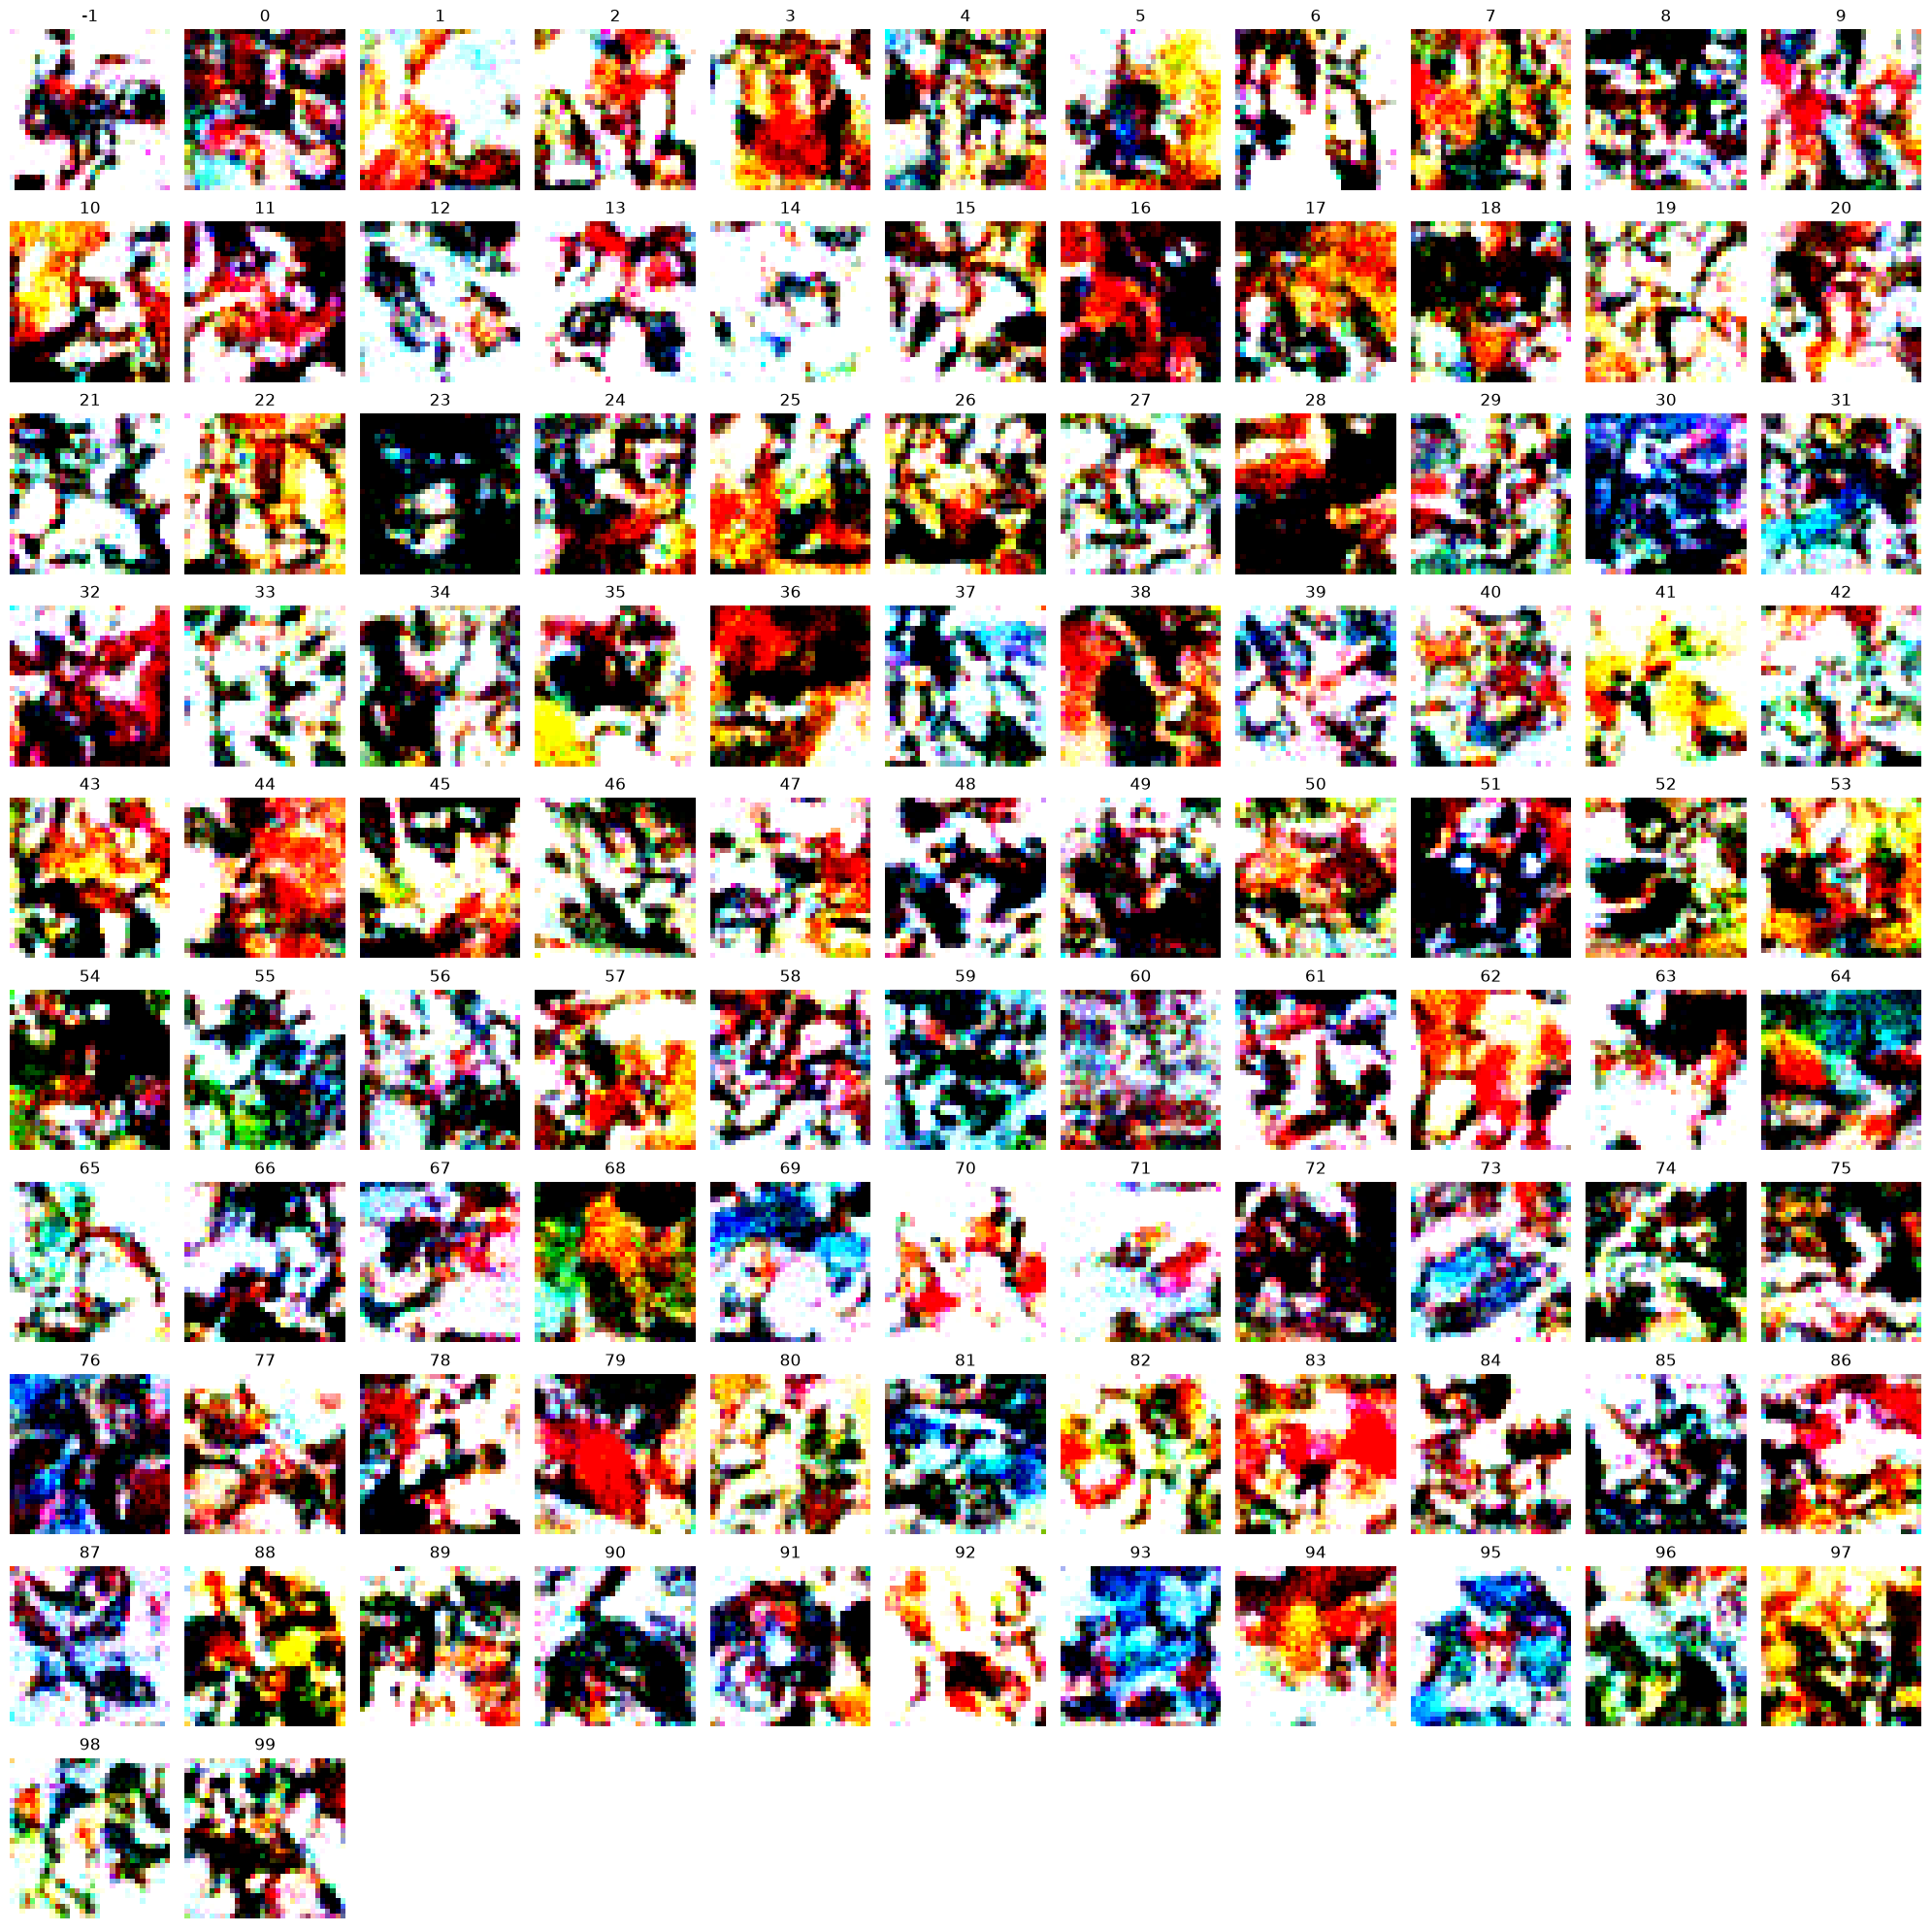

Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0316 - val_image_loss: 0.2076 - val_loss: 0.0415 - val_noise_loss: 0.0415 - learning_rate: 8.9080e-04
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - noise_loss: 0.0309 - val_image_loss: 0.1612 - val_loss: 0.0349 - val_noise_loss: 0.0349 - learning_rate: 8.7928e-04
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0310 - val_image_loss: 0.1554 - val_loss: 0.0320 - val_noise_loss: 0.0320 - learning_rate: 8.6612e-04
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0306 - val_image_loss: 0.1353 - val_loss: 0.0310 - val_noise_loss: 0.0310 - learning_rate: 8.5136e-04
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0302 - val_image_loss: 0.1160 - val_loss: 0.0295 - val_noise_loss: 0.0295 - learning_rate: 8.3506e-04
Steps: 50/50


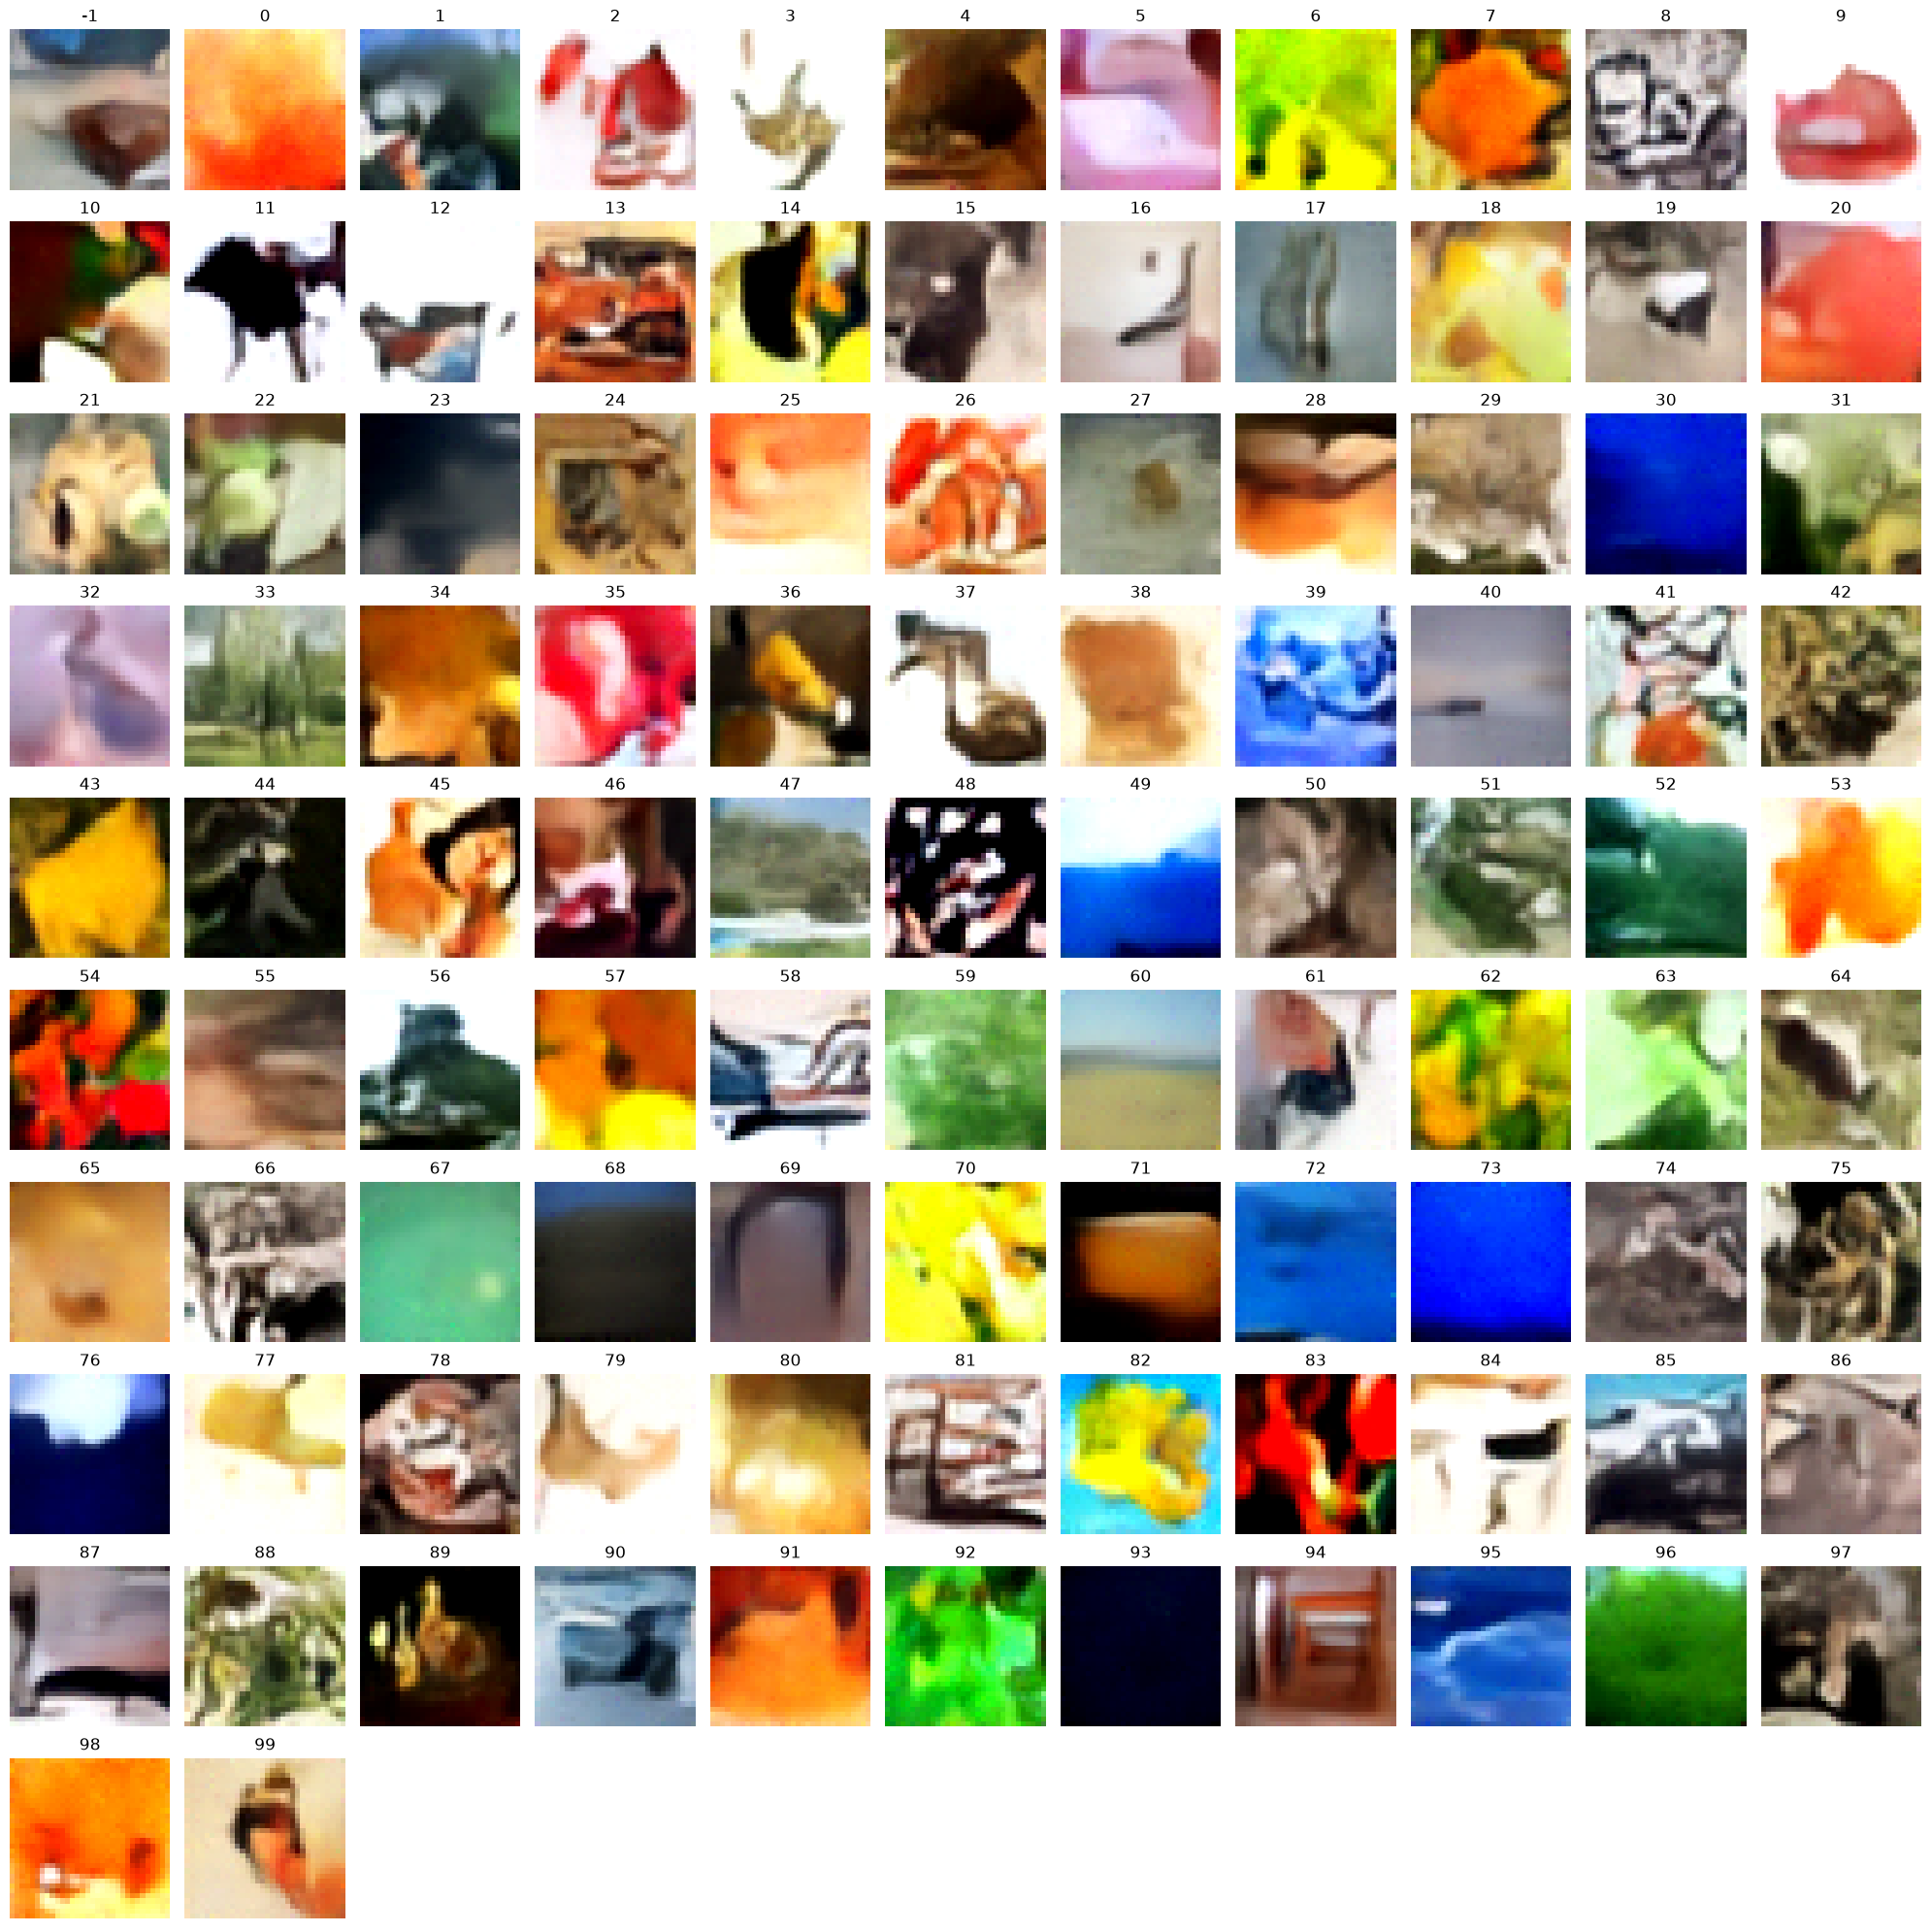

Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - noise_loss: 0.0303 - val_image_loss: 0.0949 - val_loss: 0.0295 - val_noise_loss: 0.0295 - learning_rate: 8.1728e-04
Epoch 12/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - noise_loss: 0.0297 - val_image_loss: 0.0893 - val_loss: 0.0289 - val_noise_loss: 0.0289 - learning_rate: 7.9811e-04
Epoch 13/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0299 - val_image_loss: 0.0896 - val_loss: 0.0295 - val_noise_loss: 0.0295 - learning_rate: 7.7760e-04
Epoch 14/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - noise_loss: 0.0299 - val_image_loss: 0.0816 - val_loss: 0.0296 - val_noise_loss: 0.0296 - learning_rate: 7.5585e-04
Epoch 15/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - noise_loss: 0.0296 - val_image_loss: 0.0844 - val_loss: 0.0295 - val_noise_loss: 0.0295 - learning_rate: 7.3294e-04
Steps: 50/50


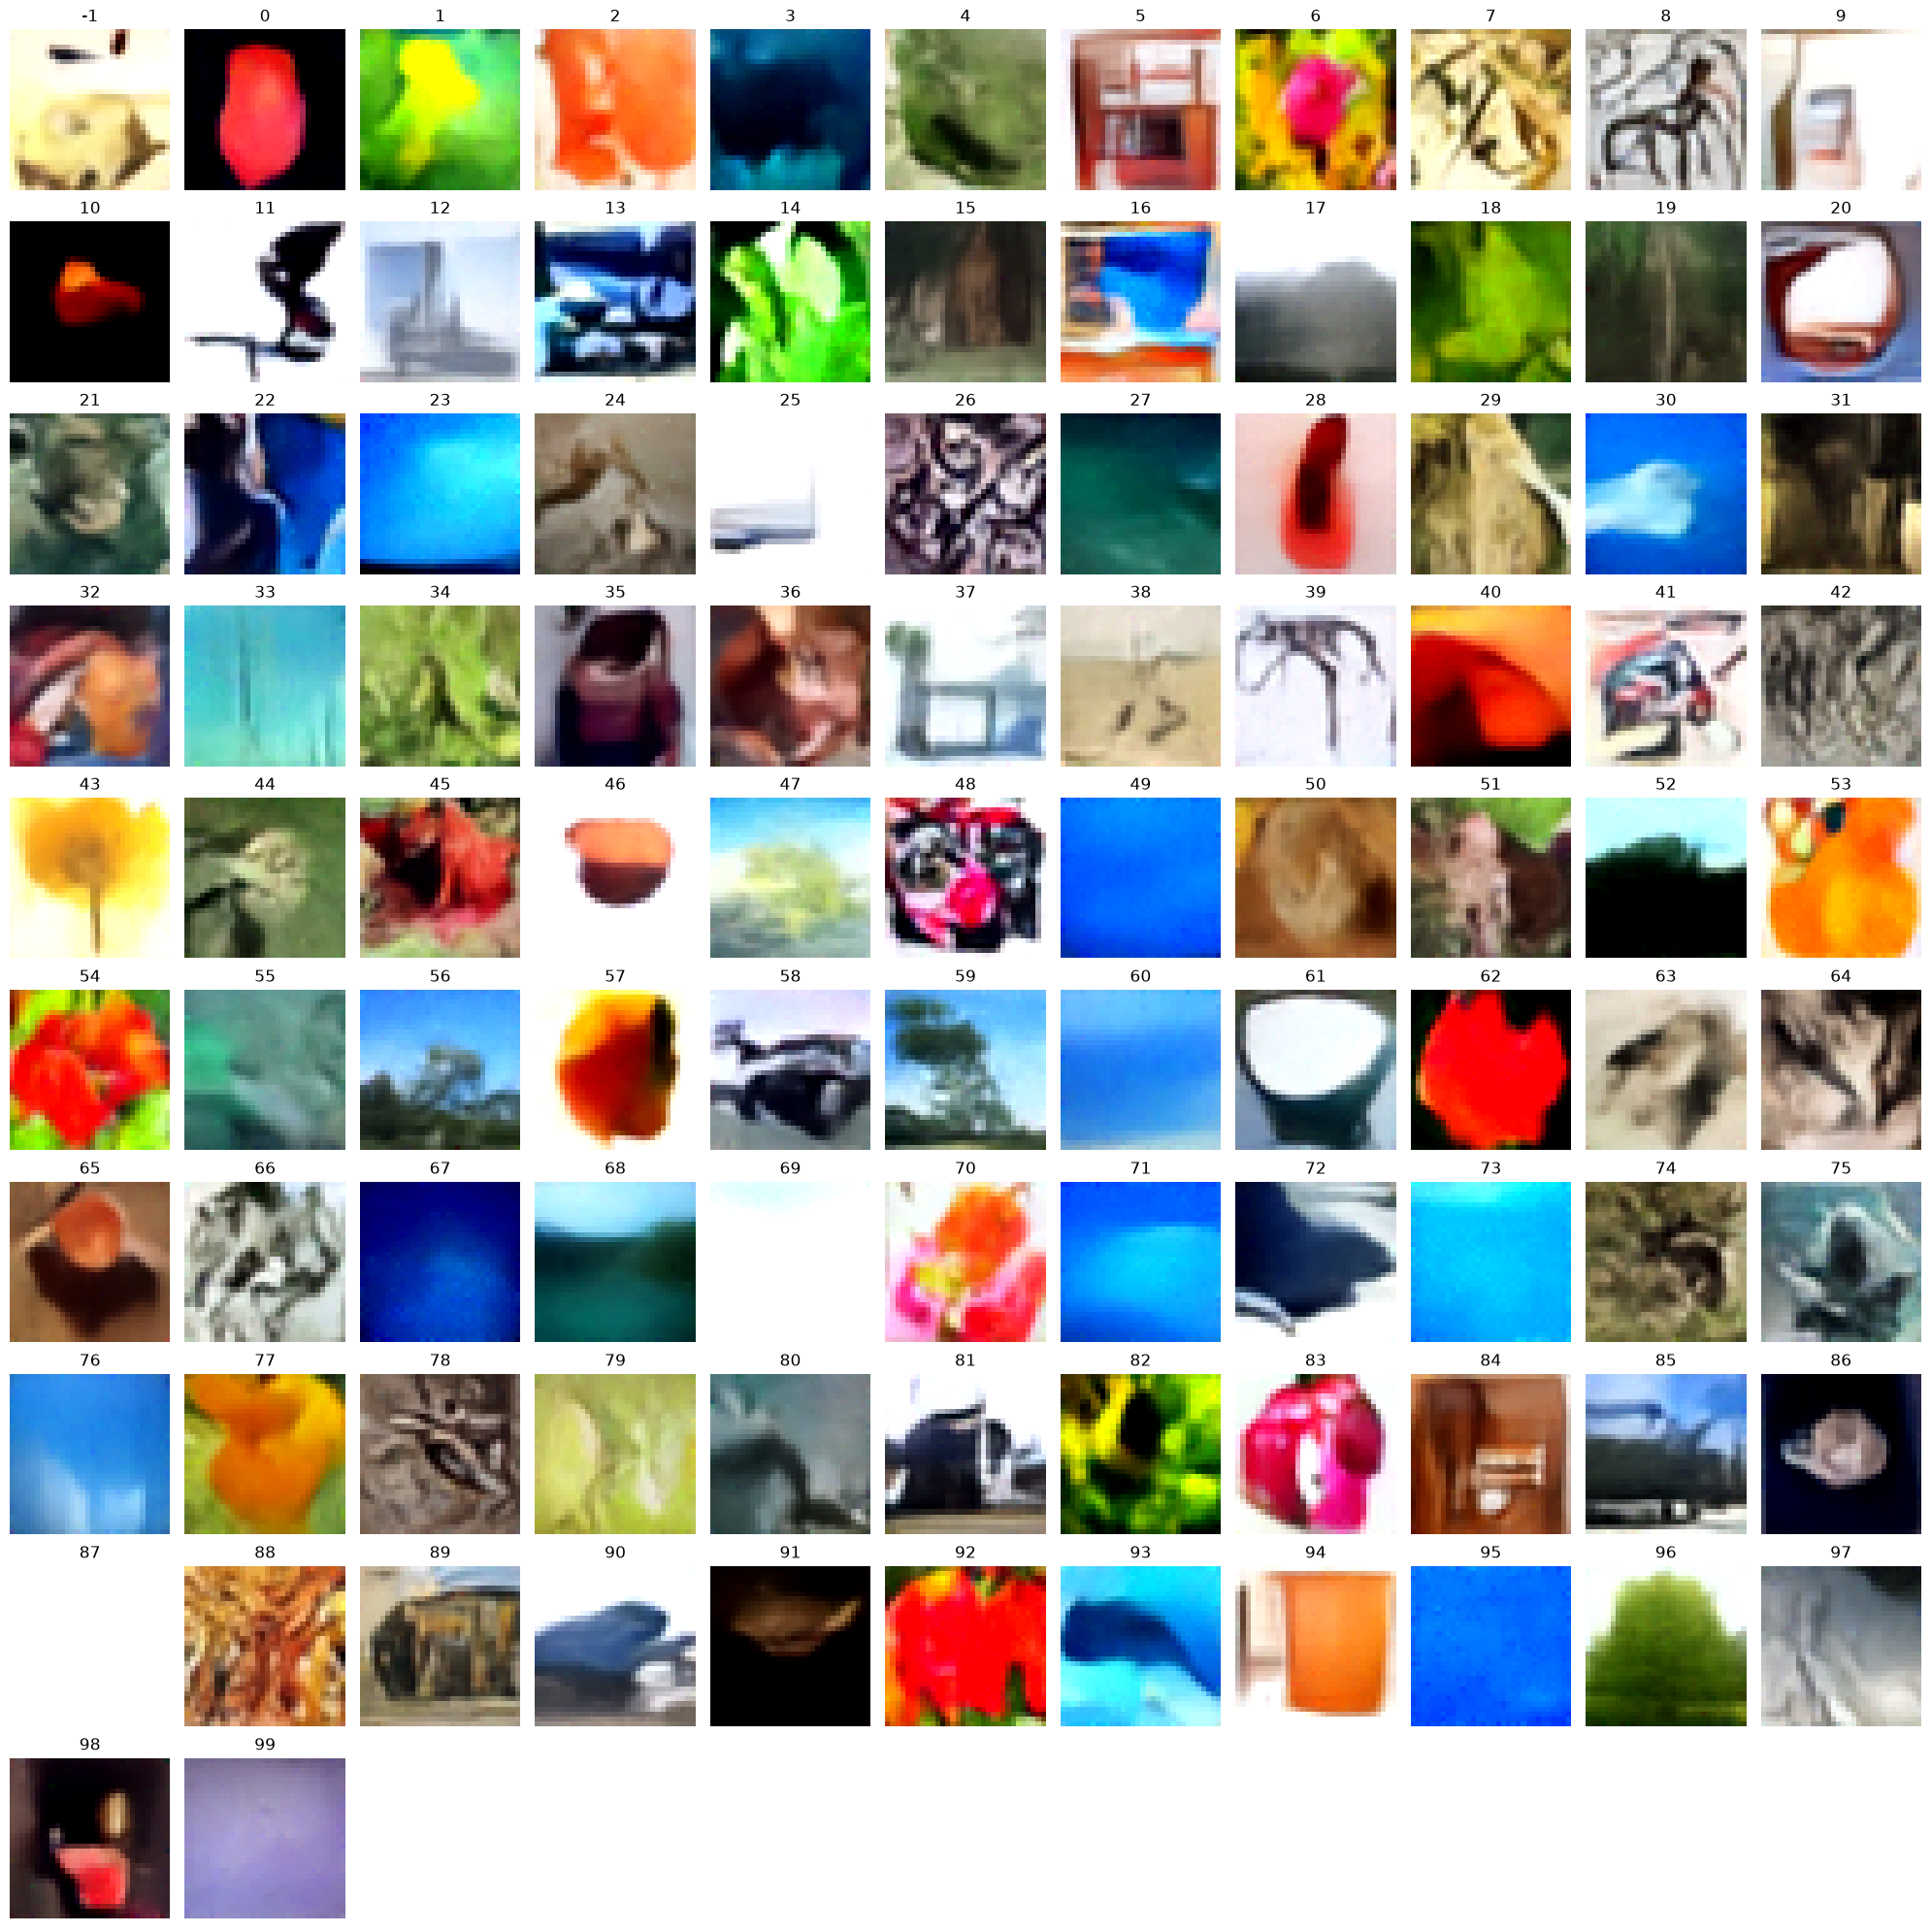

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

## Save weights

Save raw and EMA weights under a UNet-specific path. Rerunning this cell replaces this notebook's checkpoint.


In [9]:
model.save_weights("./files/models/CIFAR100 UNet Diffusion 2/model.weights.h5")

## Evaluate EMA and raw networks

Report diffusion losses for both networks on the same monitoring split.


In [10]:
model.evaluate(valset, network_name="ema")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - image_loss: 0.1126 - loss: 0.0302 - noise_loss: 0.0302


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03019905276596546>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03019905276596546>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.11258365958929062>]

In [11]:
model.evaluate(valset, network_name="raw")

157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - image_loss: 0.1474 - loss: 0.0324 - noise_loss: 0.0324


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03239570930600166>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03239570930600166>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.14740562438964844>]

## Class-conditional samples

Compare 1,000 stochastic steps, 1,000 deterministic steps, and 50 deterministic steps at guidance scales 3 and 4 using the EMA network. The first image is the null condition, followed by all 100 classes. Explicit sampling condition IDs are 1–100; 0 is null. The wrapper already maps images to external pixel values. Sampling stream counters advance between calls even with a fixed seed; these grids are illustrative comparisons, not paired-noise measurements.

Default previews now contain 101 images (100 classes plus the null condition). The original sampling settings and preview frequency are preserved; increasing val_freq reduces preview overhead.


Steps: 1000/1000


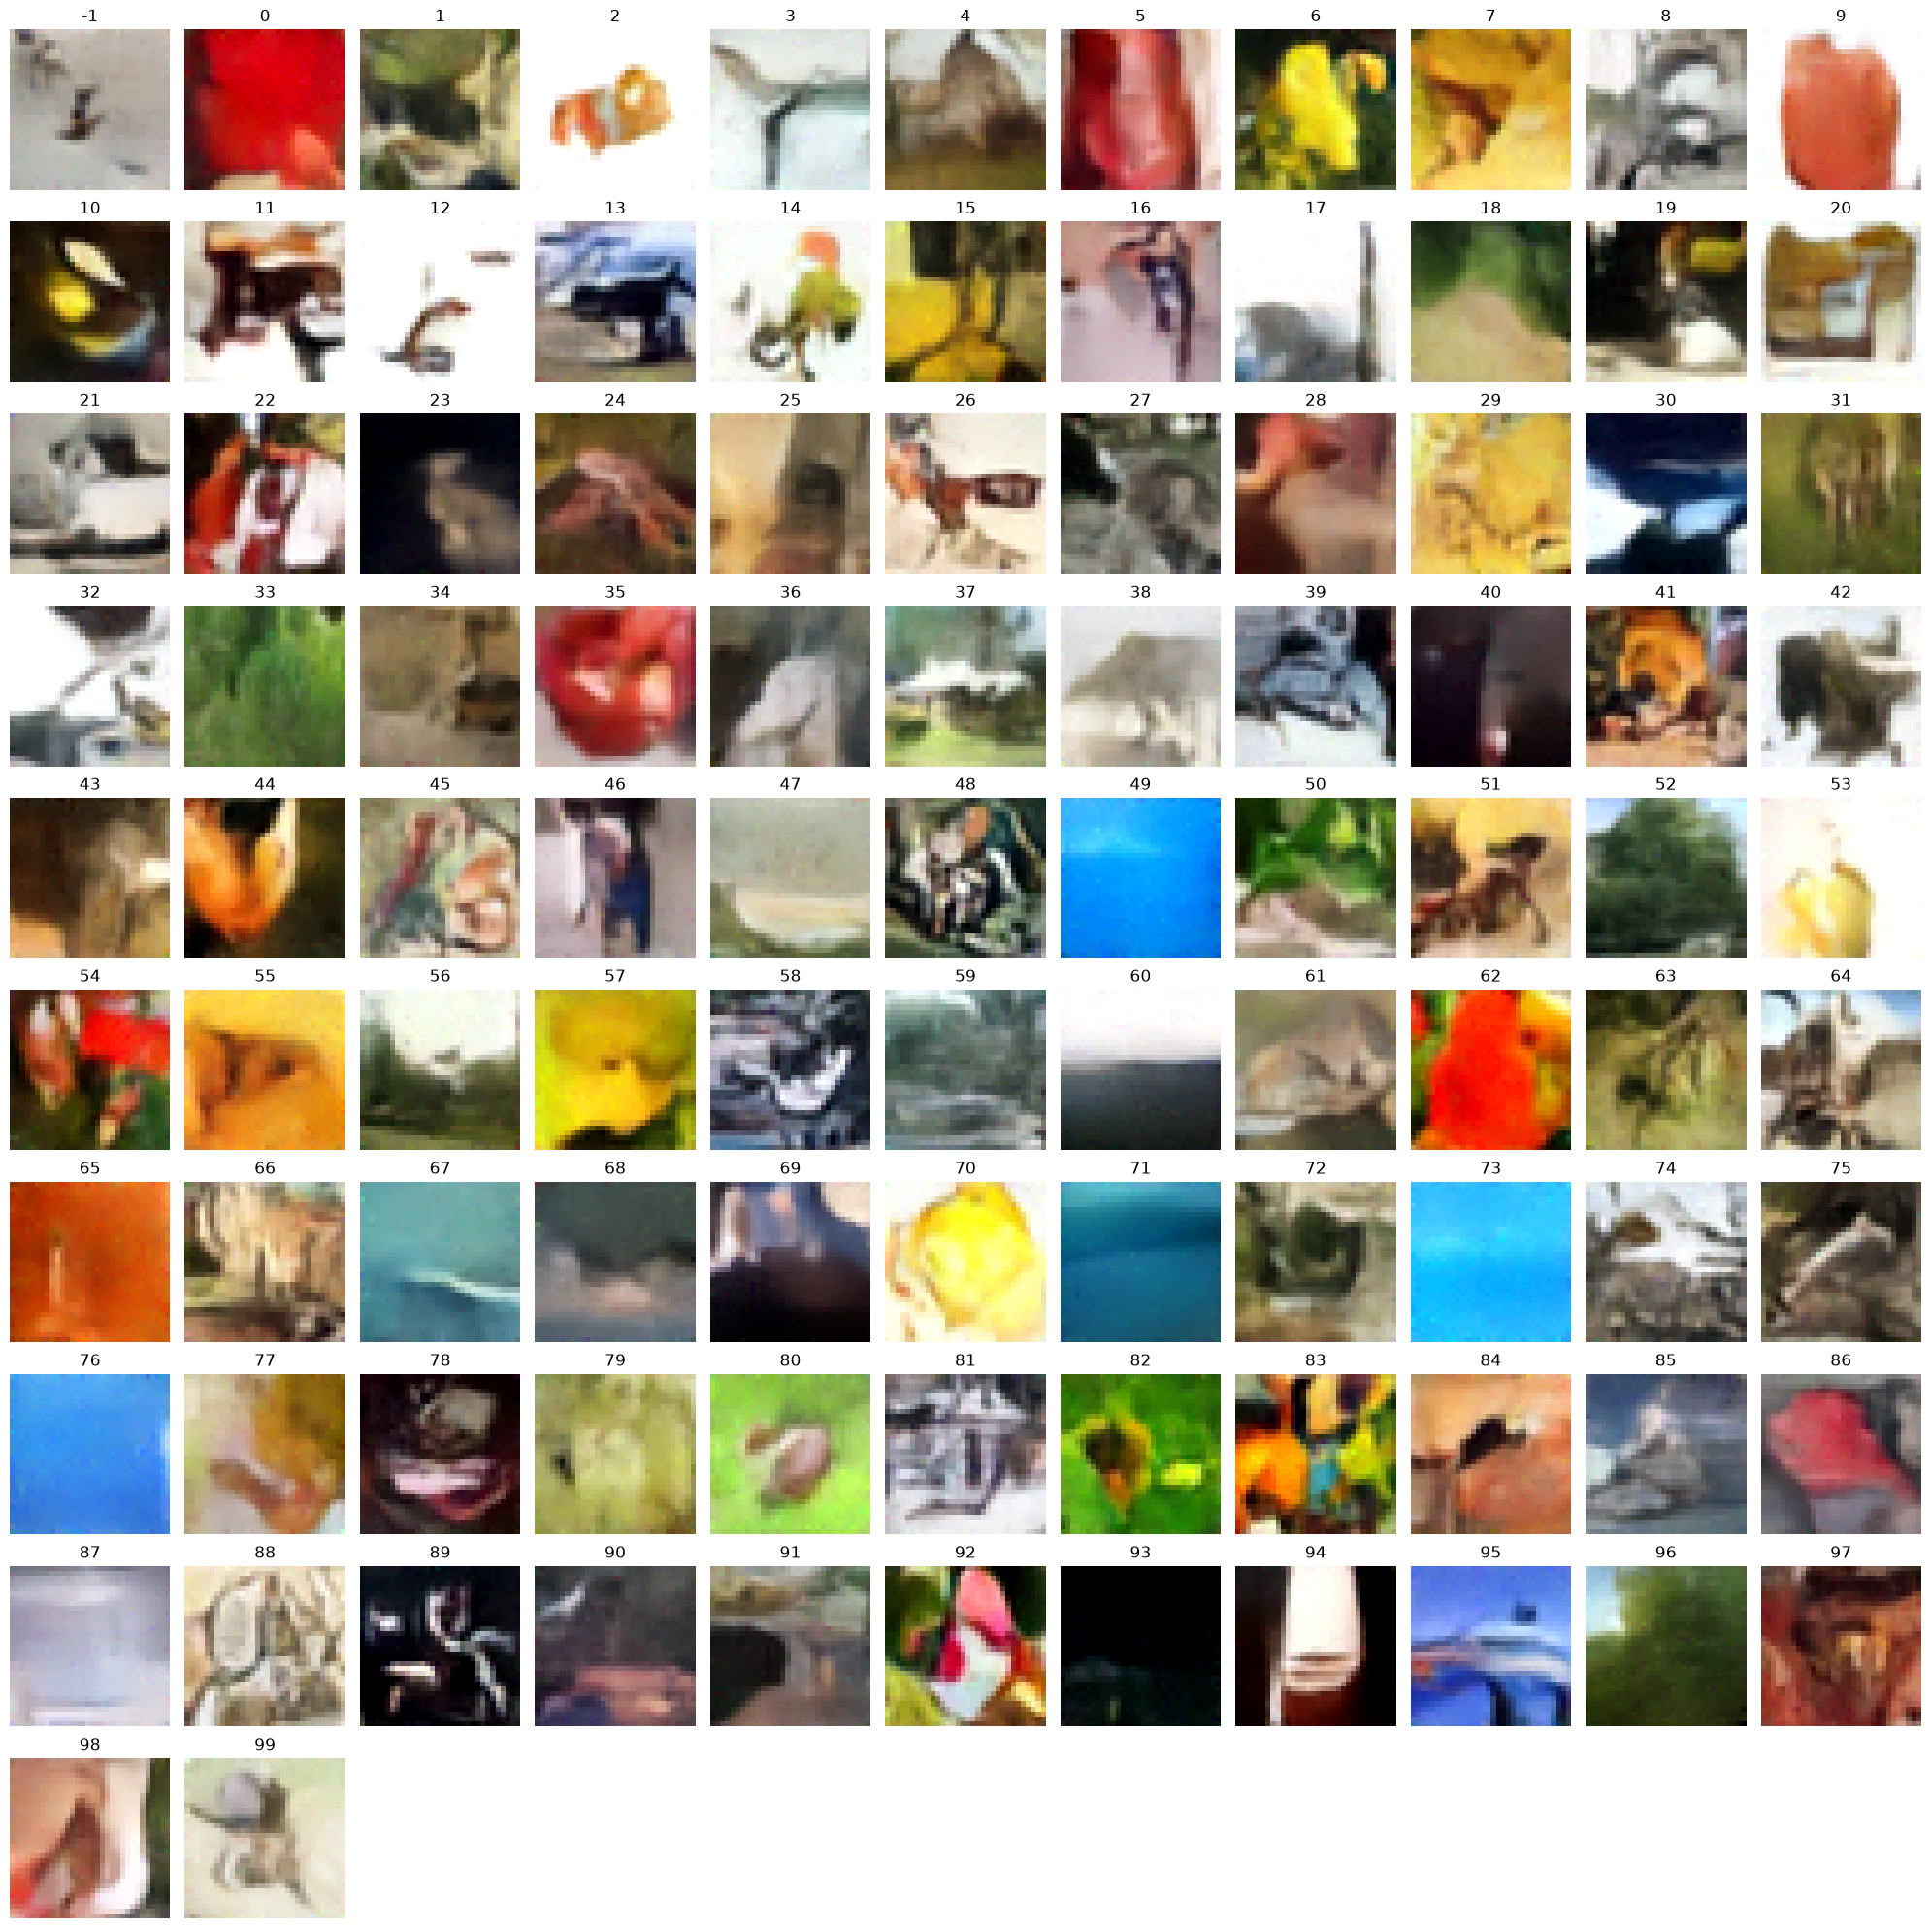

In [12]:
from common.utils import plot_images


imgs = model.sample(
    add_null_label=True, 
    scale=3.0, 
    eta=1.0, 
    steps=1000, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


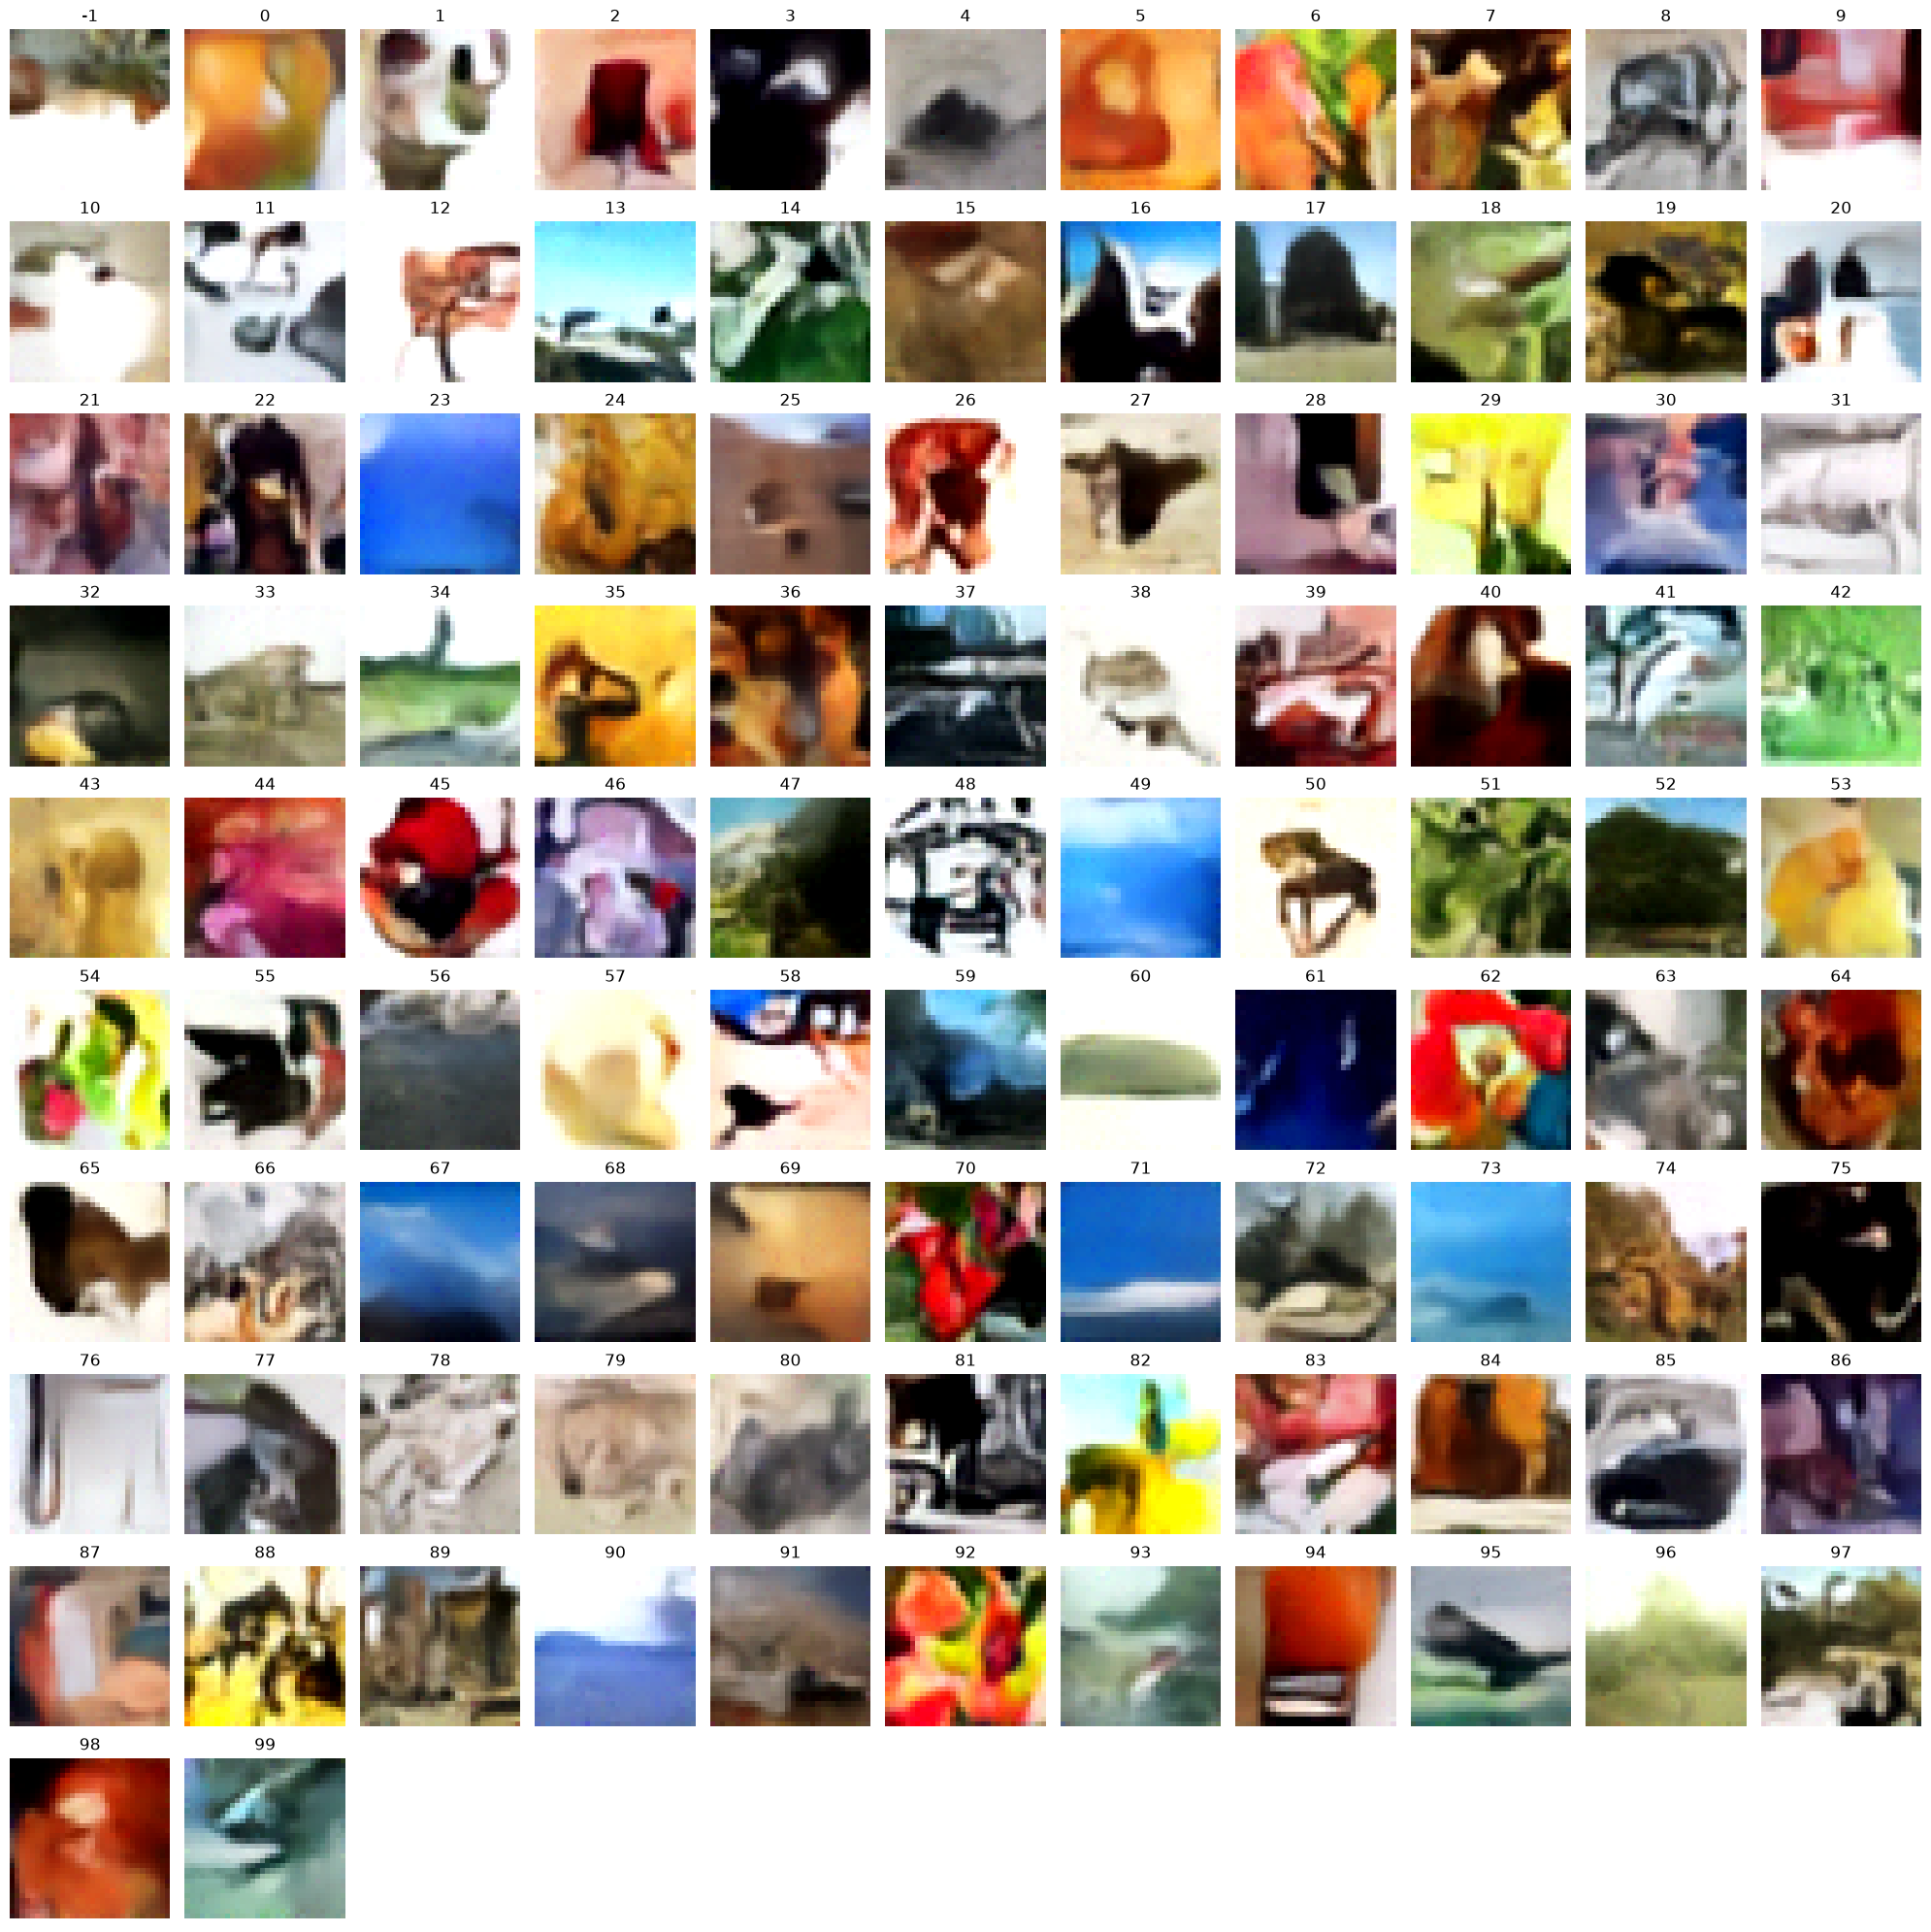

In [13]:
imgs = model.sample(
    add_null_label=True, 
    scale=3.0, 
    eta=0.0, 
    steps=1000, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 50/50


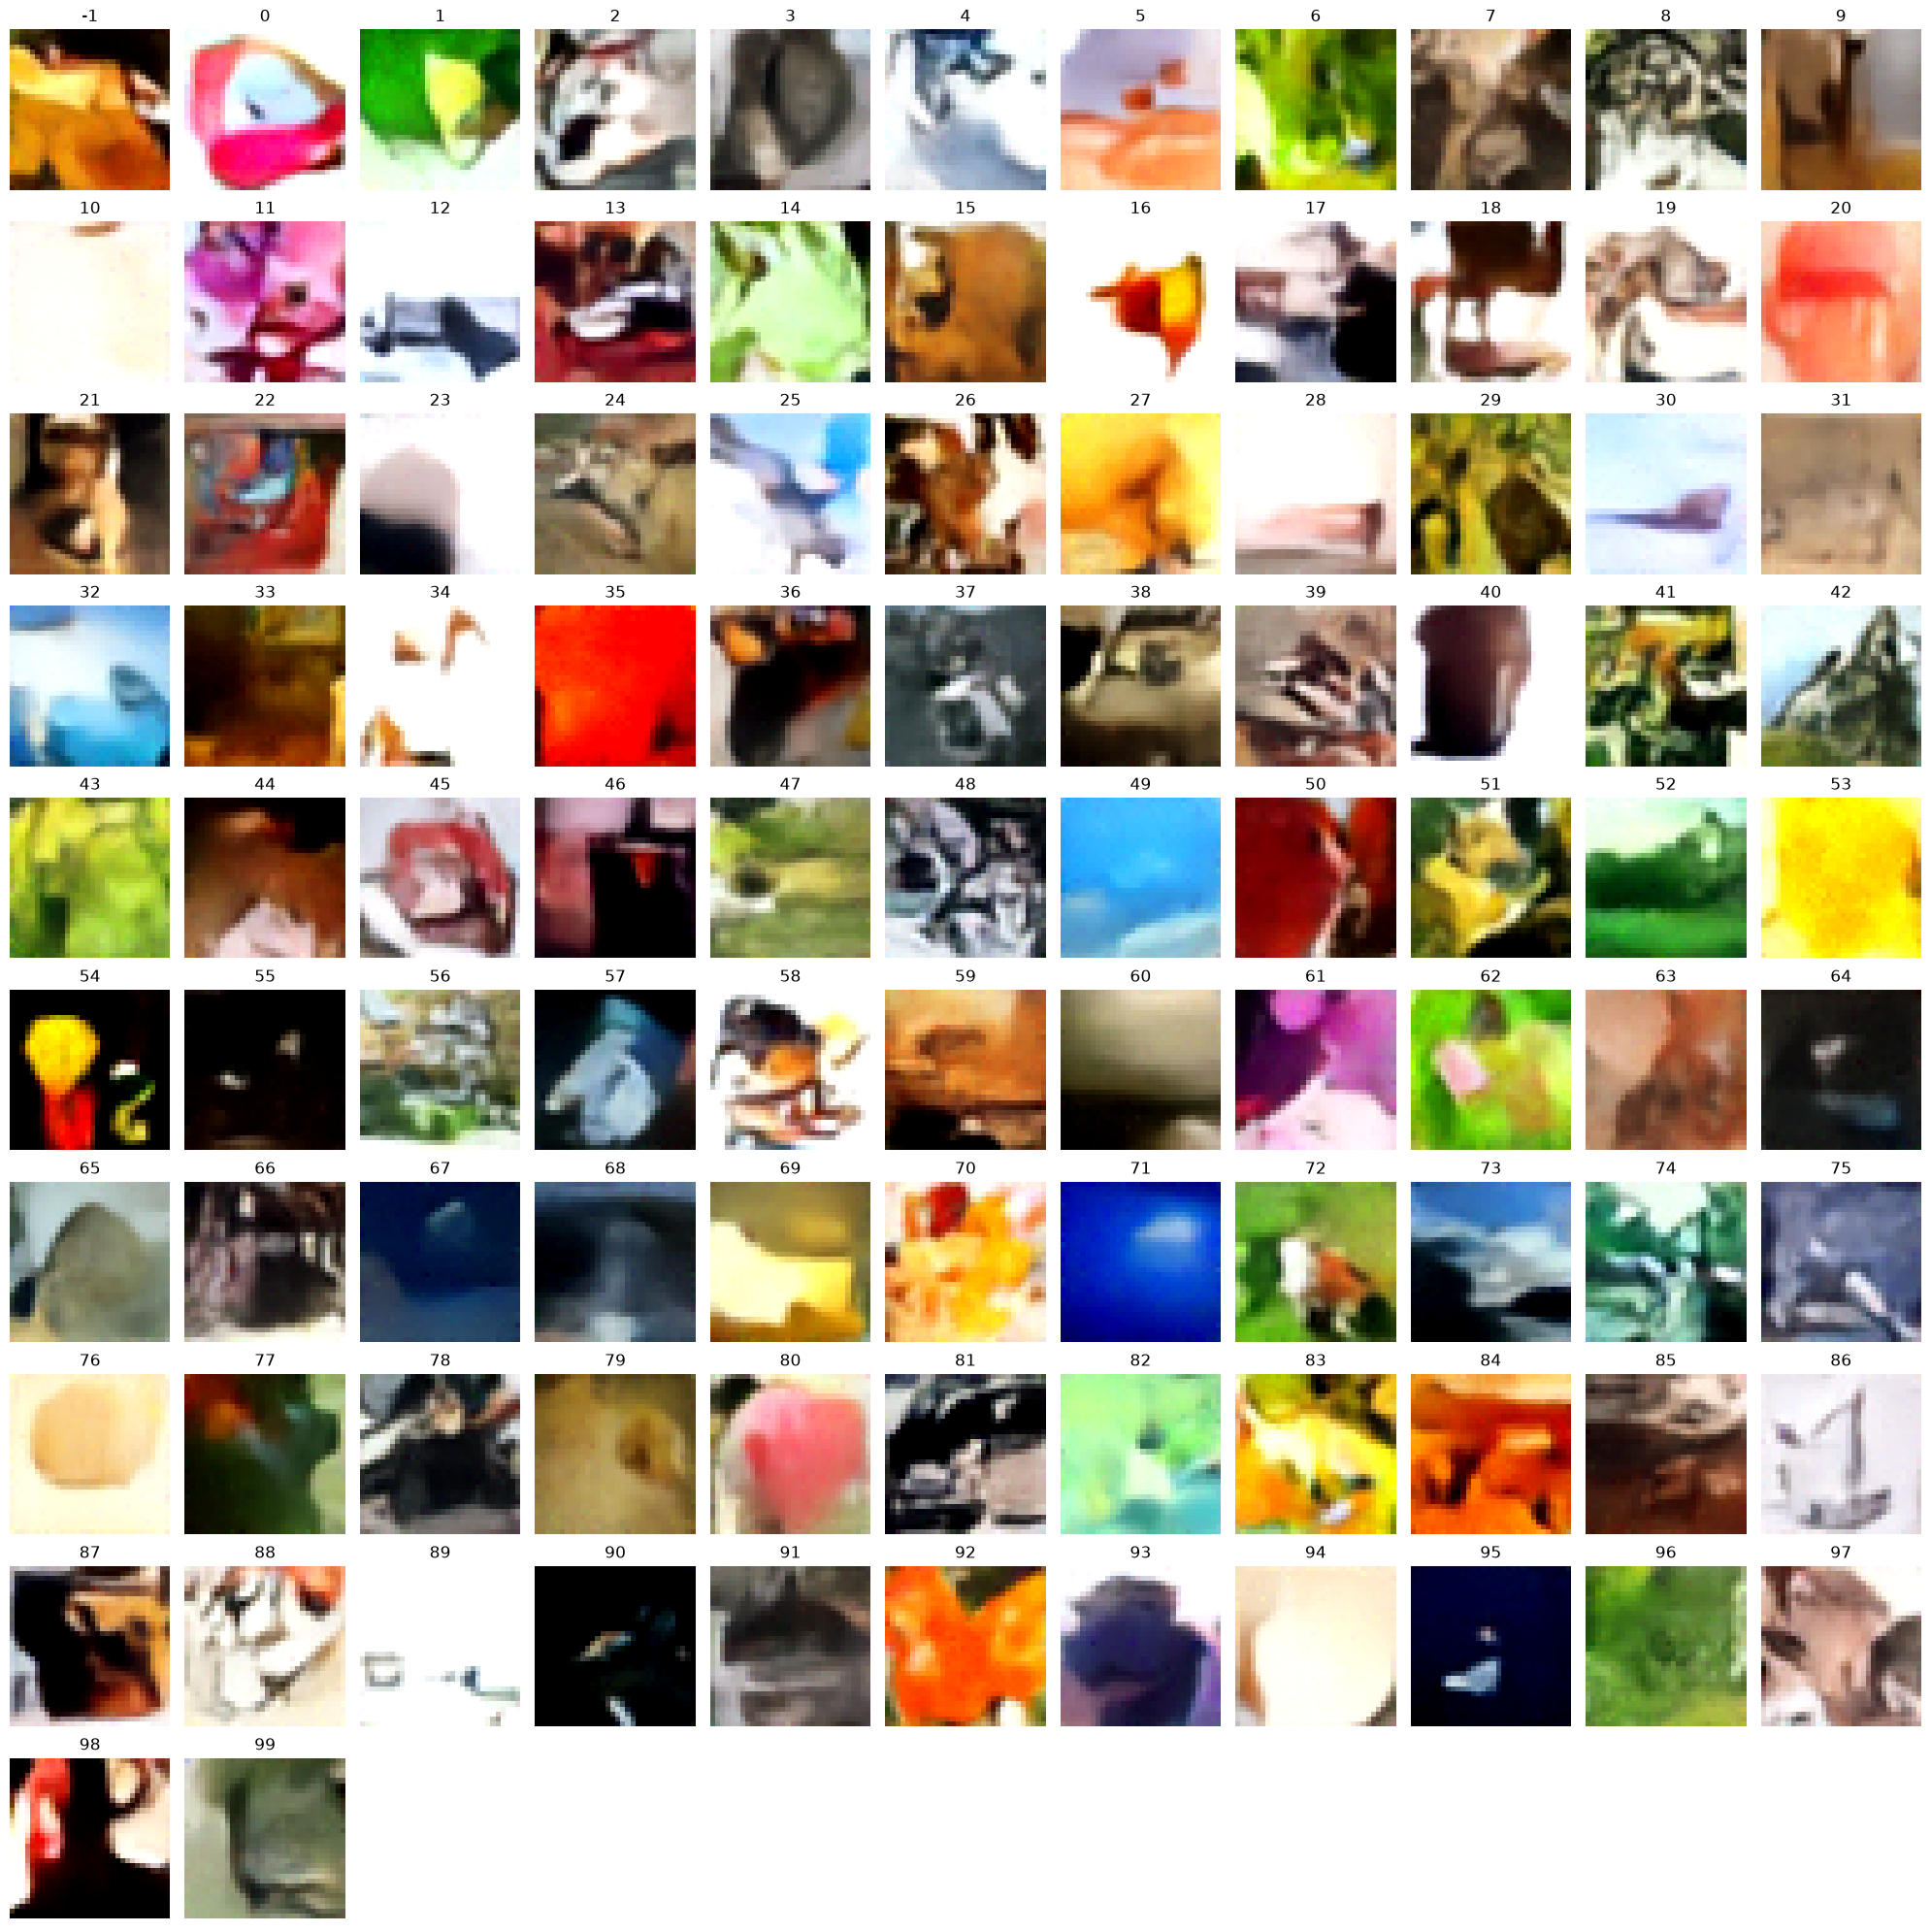

In [14]:
imgs = model.sample(
    add_null_label=True, 
    scale=3.0, 
    eta=0.0, 
    steps=50, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 50/50


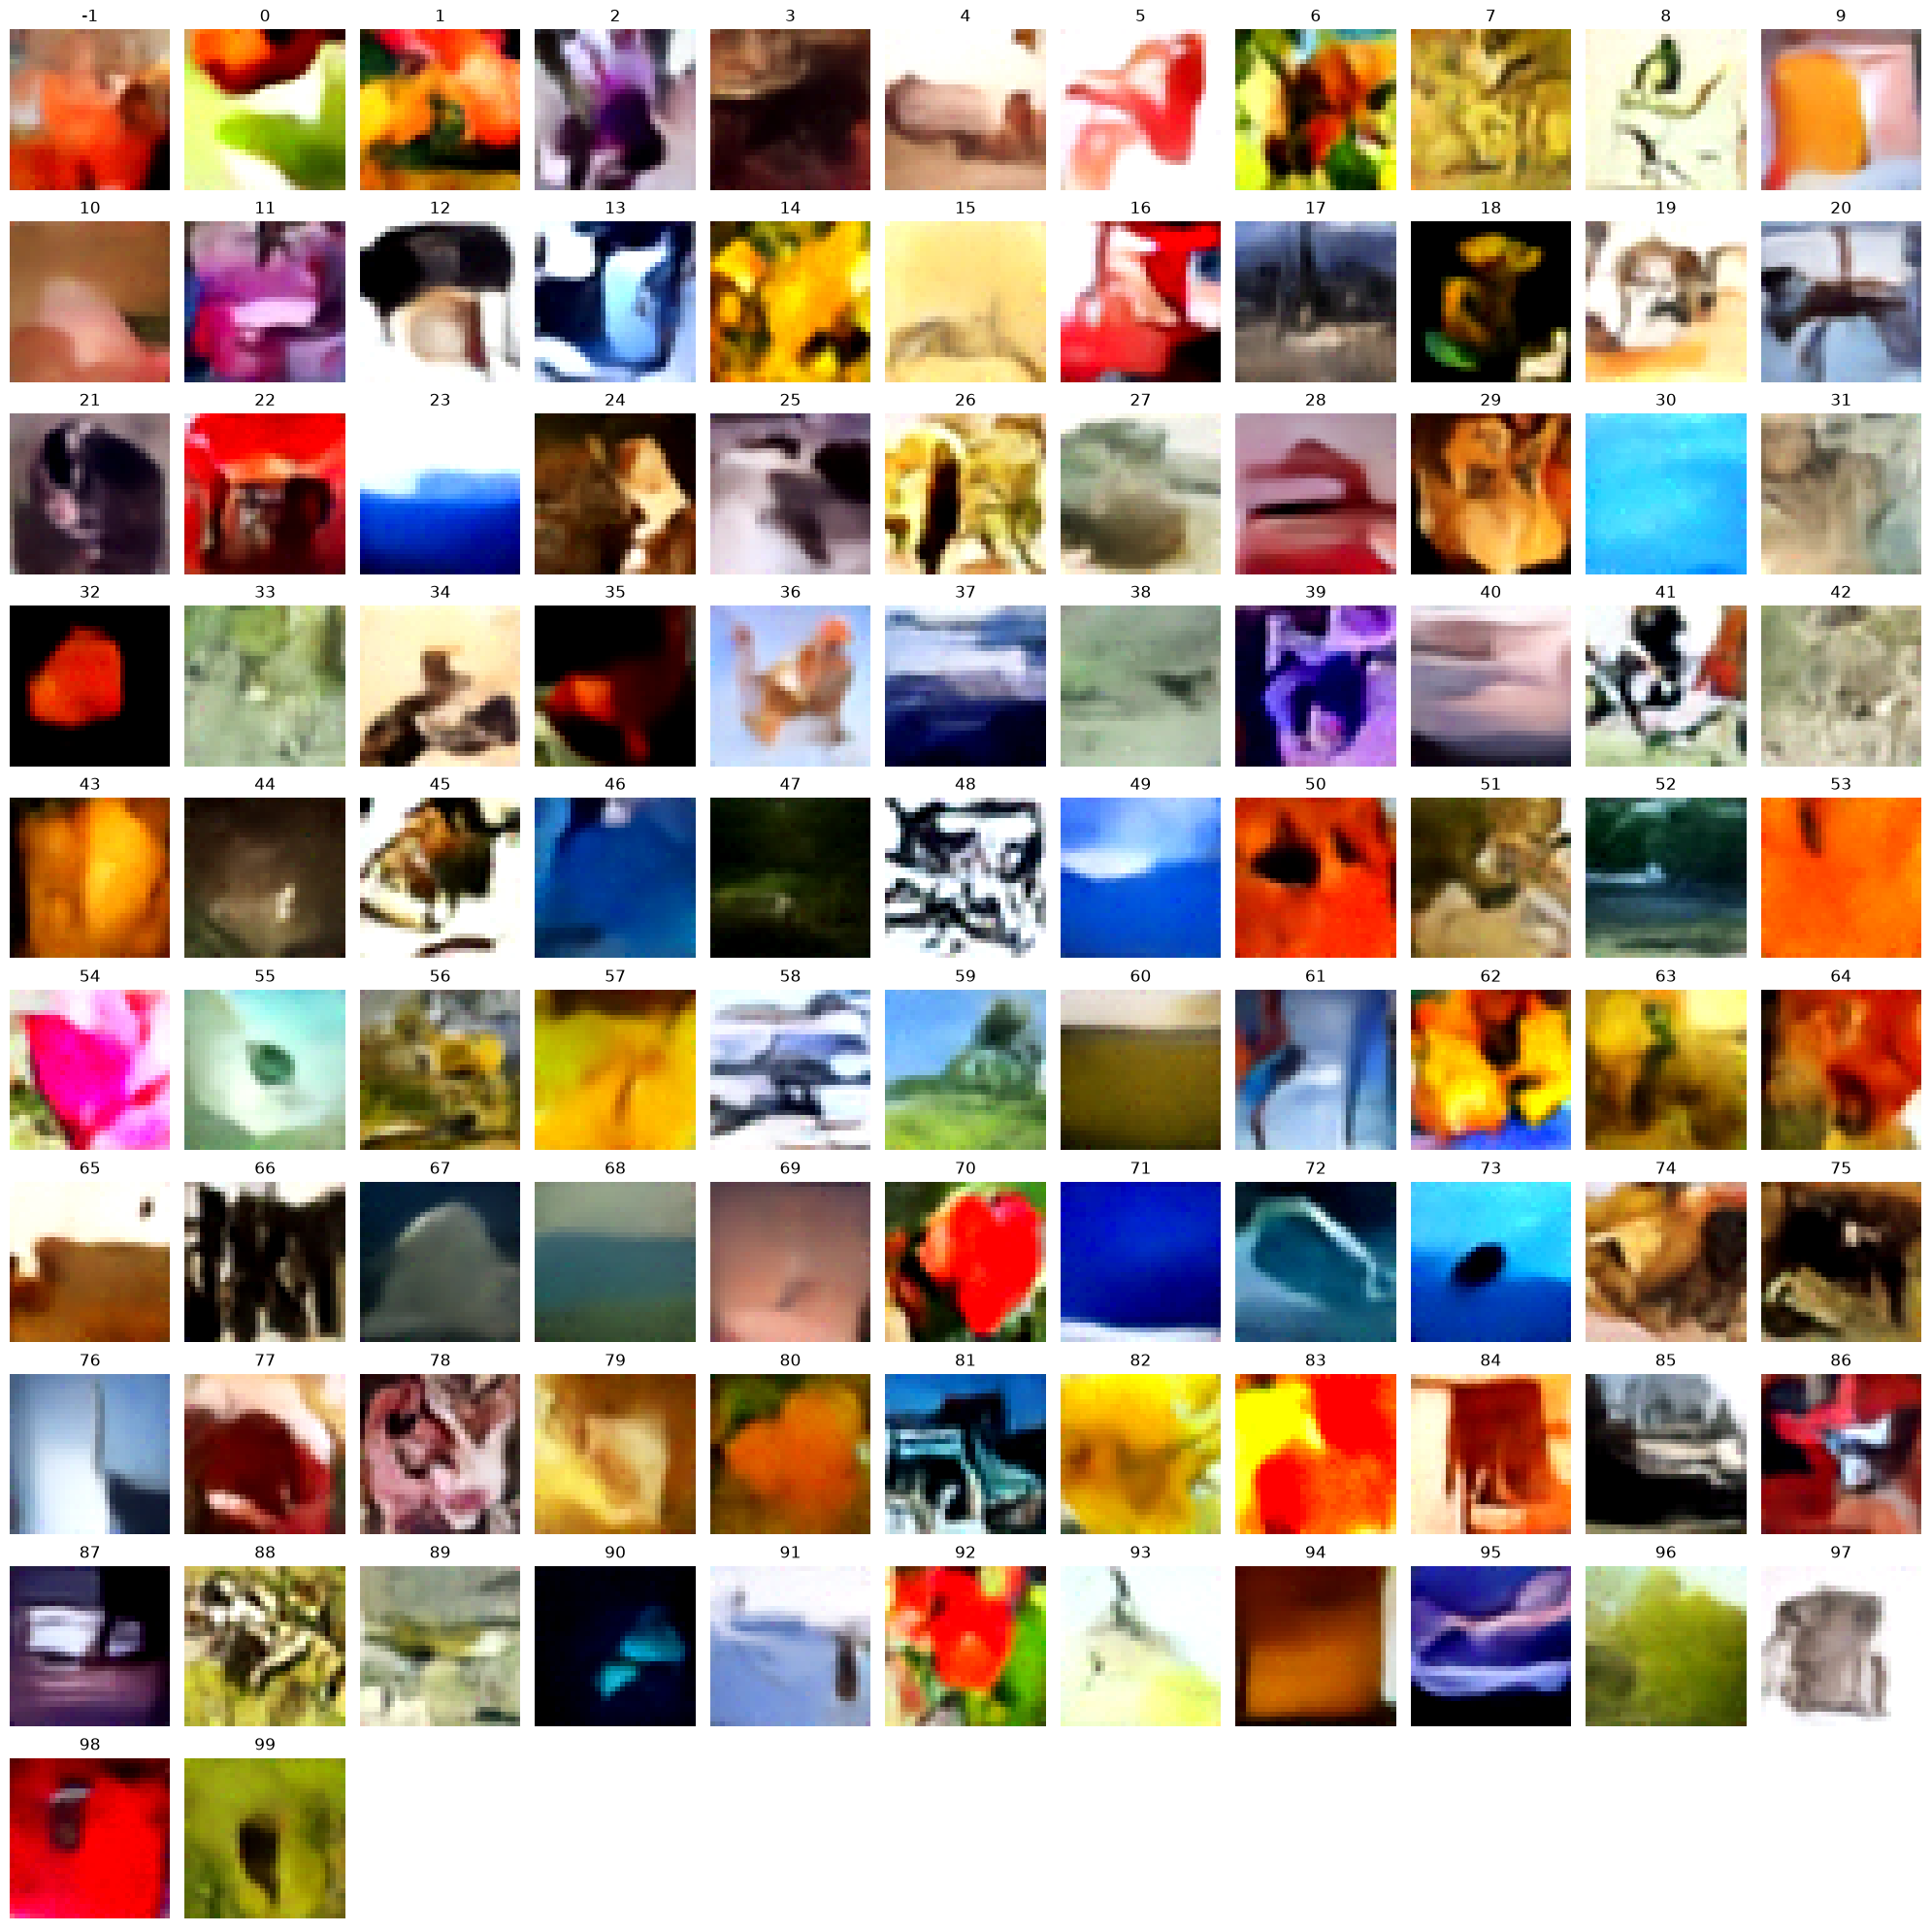

In [15]:
imgs = model.sample(
    add_null_label=True, 
    scale=4.0, 
    eta=0.0, 
    steps=50, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

## Training history

Plot all recorded metrics, including validation-only diagnostics such as val_image_loss. The first plot infers validation spacing automatically. The second uses the known validation frequency and starts at zero-based epoch index 9 (epoch 10 onward), retaining every validation observation in that epoch range.


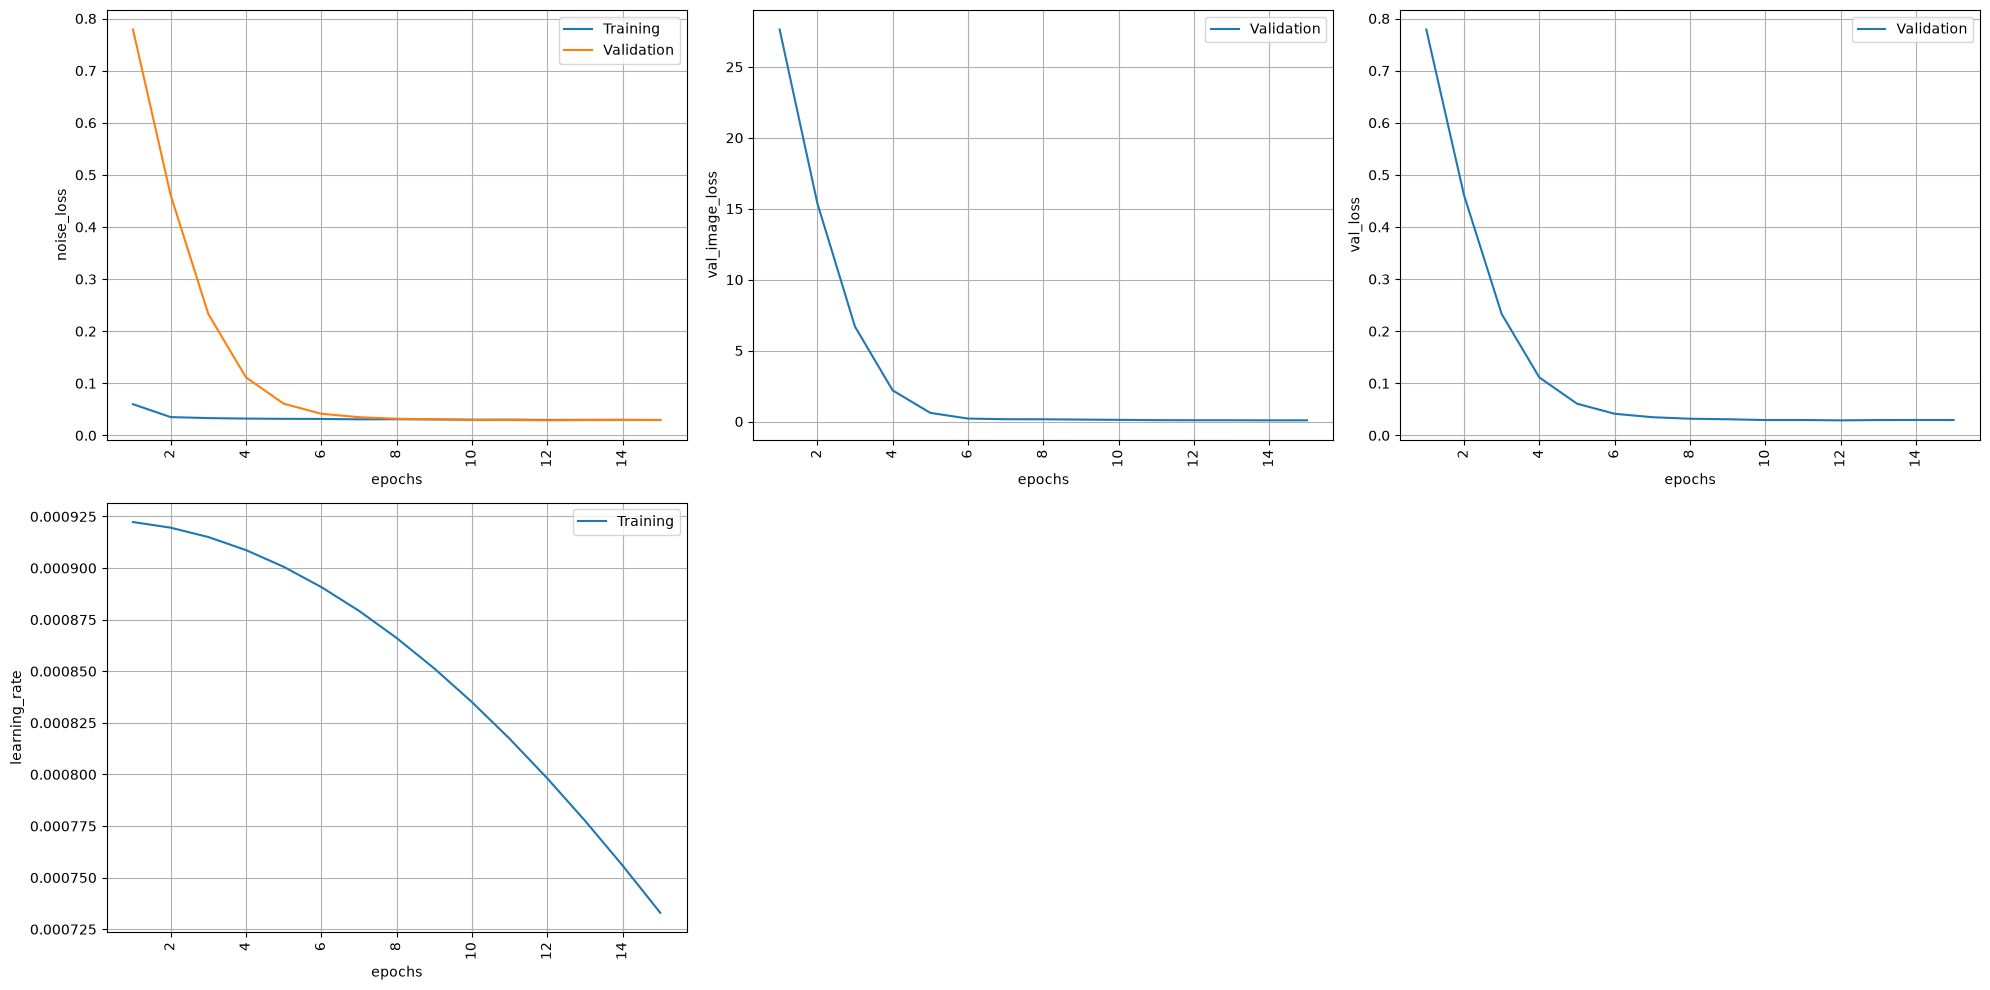

In [16]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False)

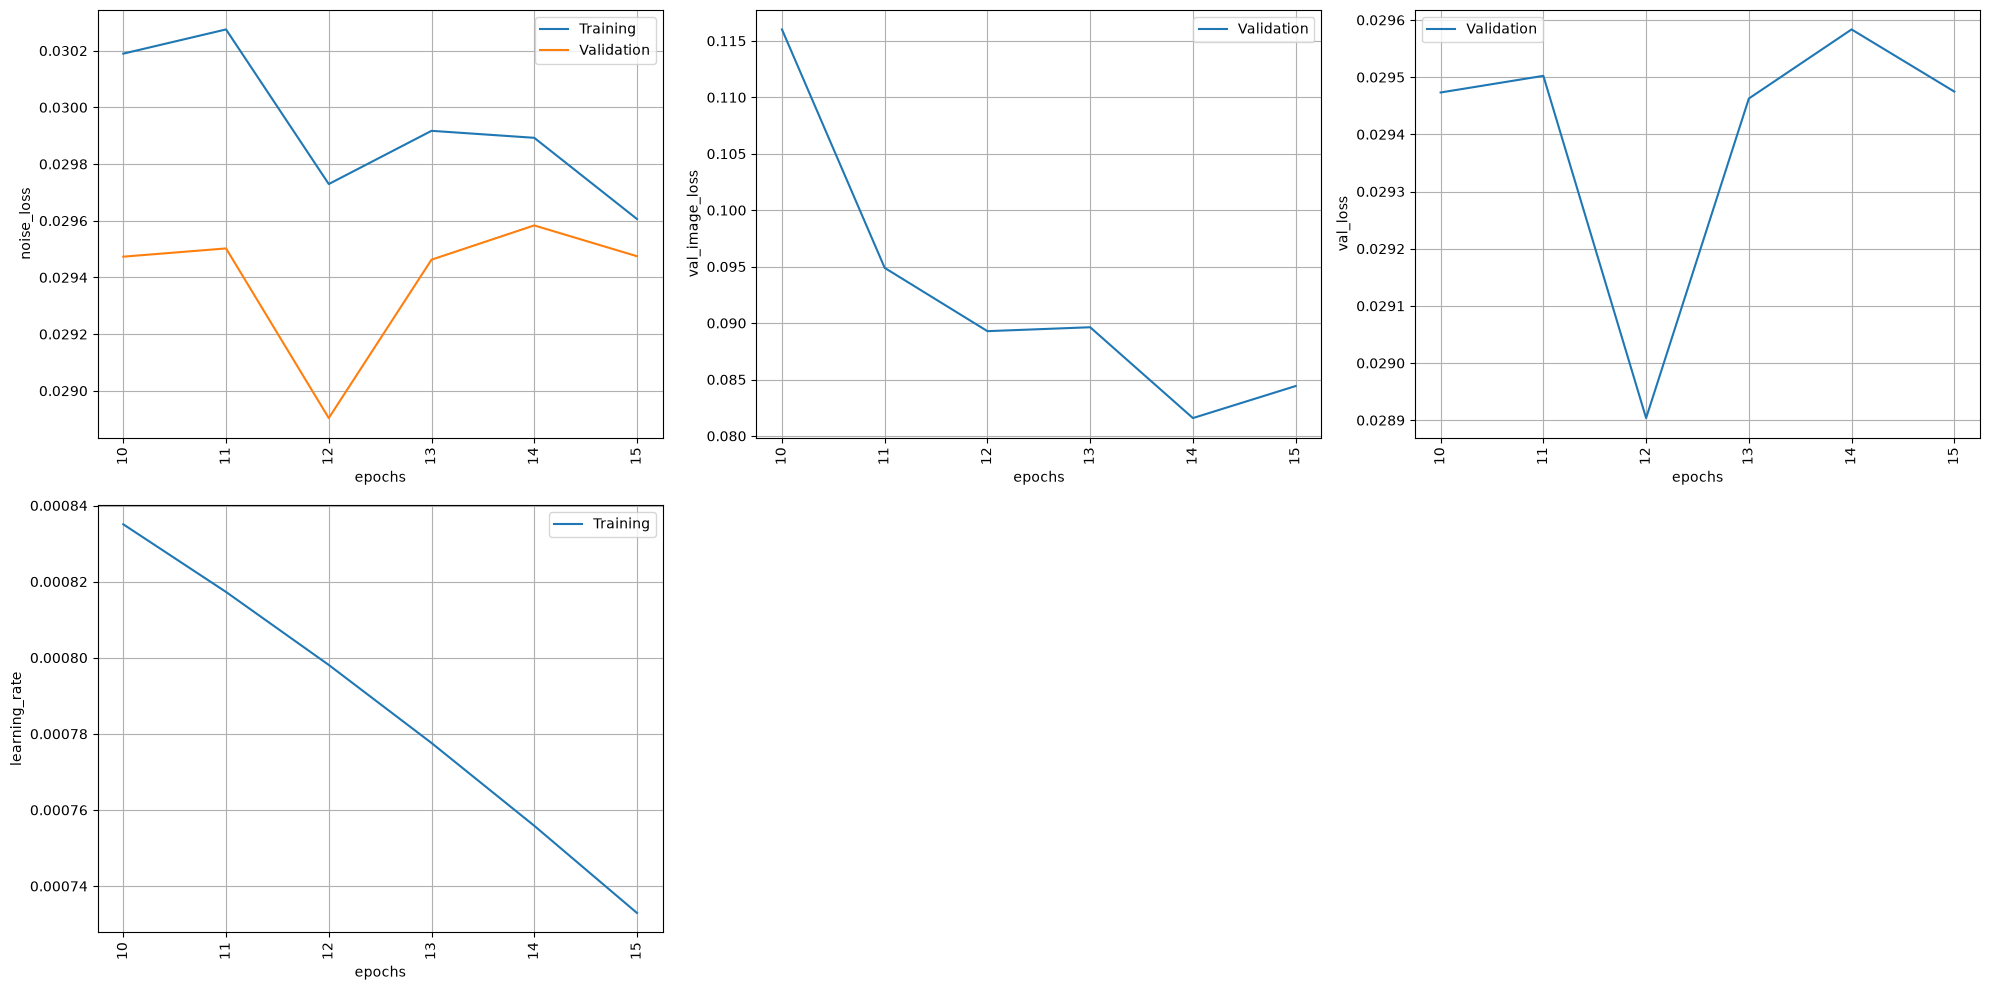

In [17]:
plot_history(history, show_all_x_ticks=False, range_=(9, None))